# Regressão Logística 
Este notebook cobre a família de modelos de Regressão Logística. Aqui comparamos três variações de LR

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, PowerTransformer, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

DATA_DIR = Path('.')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
TARGET = 'smoking'
ID_COL = 'id'
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


## 2. Carregamento dos dados

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')
display(train.head())

Train: (159256, 24)
Test:  (106171, 23)


,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,87,94,172,300,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,83,147,194,55,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,75,79,178,197,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,88,91,180,203,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,76,91,155,87,44,93,15.4,1,0.8,19,13,17,0,1


In [3]:
summary = pd.DataFrame({
    'dtype': train.dtypes,
    'missing_train': train.isna().sum(),
    'missing_test': test.reindex(columns=train.columns.drop(TARGET)).isna().sum(),
    'nunique_train': train.nunique(),
})
display(summary)

print('Distribuicao do alvo:')
display(train[TARGET].value_counts().rename('count').to_frame().assign(rate=lambda x: x['count'] / len(train)))

,dtype,missing_train,missing_test,nunique_train
ALT,int64,0,0.0,188
AST,int64,0,0.0,140
Cholesterol,int64,0,0.0,227
Gtp,int64,0,0.0,362
HDL,int64,0,0.0,108
LDL,int64,0,0.0,222
Urine protein,int64,0,0.0,6
age,int64,0,0.0,18
dental caries,int64,0,0.0,2
eyesight(left),float64,0,0.0,20


Distribuicao do alvo:


,count,rate
smoking,,
0,89603,0.562635
1,69653,0.437365


## 3. EDA inicial

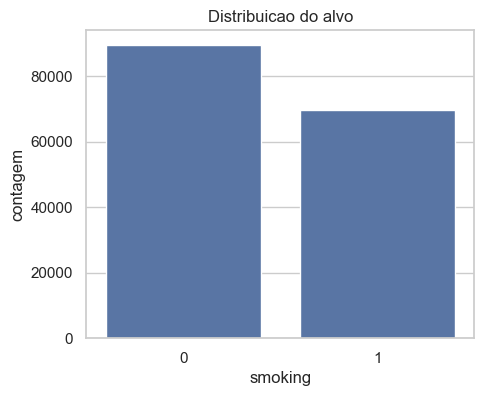

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train, x=TARGET, ax=ax)
ax.set_title('Distribuicao do alvo')
ax.set_xlabel('smoking')
ax.set_ylabel('contagem')
plt.show()

In [5]:
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
continuous_cols = [
    c for c in feature_cols
    if train[c].nunique() > 10
]
discrete_cols = [c for c in feature_cols if c not in continuous_cols]

print('Continuas:', continuous_cols)
print('Discretas/categoricas:', discrete_cols)

Continuas: ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'serum creatinine', 'AST', 'ALT', 'Gtp']
Discretas/categoricas: ['hearing(left)', 'hearing(right)', 'Urine protein', 'dental caries']


In [6]:
train[continuous_cols].describe().T.style.format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max
age,159256.00,44.31,11.84,20.00,40.00,40.00,55.00,85.00
height(cm),159256.00,165.27,8.82,135.00,160.00,165.00,170.00,190.00
weight(kg),159256.00,67.14,12.59,30.00,60.00,65.00,75.00,130.00
waist(cm),159256.00,83.00,8.96,51.00,77.00,83.00,89.00,127.00
eyesight(left),159256.00,1.01,0.40,0.10,0.80,1.00,1.20,9.90
eyesight(right),159256.00,1.00,0.39,0.10,0.80,1.00,1.20,9.90
systolic,159256.00,122.50,12.73,77.00,114.00,121.00,130.00,213.00
relaxation,159256.00,76.87,8.99,44.00,70.00,78.00,82.00,133.00
fasting blood sugar,159256.00,98.35,15.33,46.00,90.00,96.00,103.00,375.00
Cholesterol,159256.00,195.80,28.40,77.00,175.00,196.00,217.00,393.00


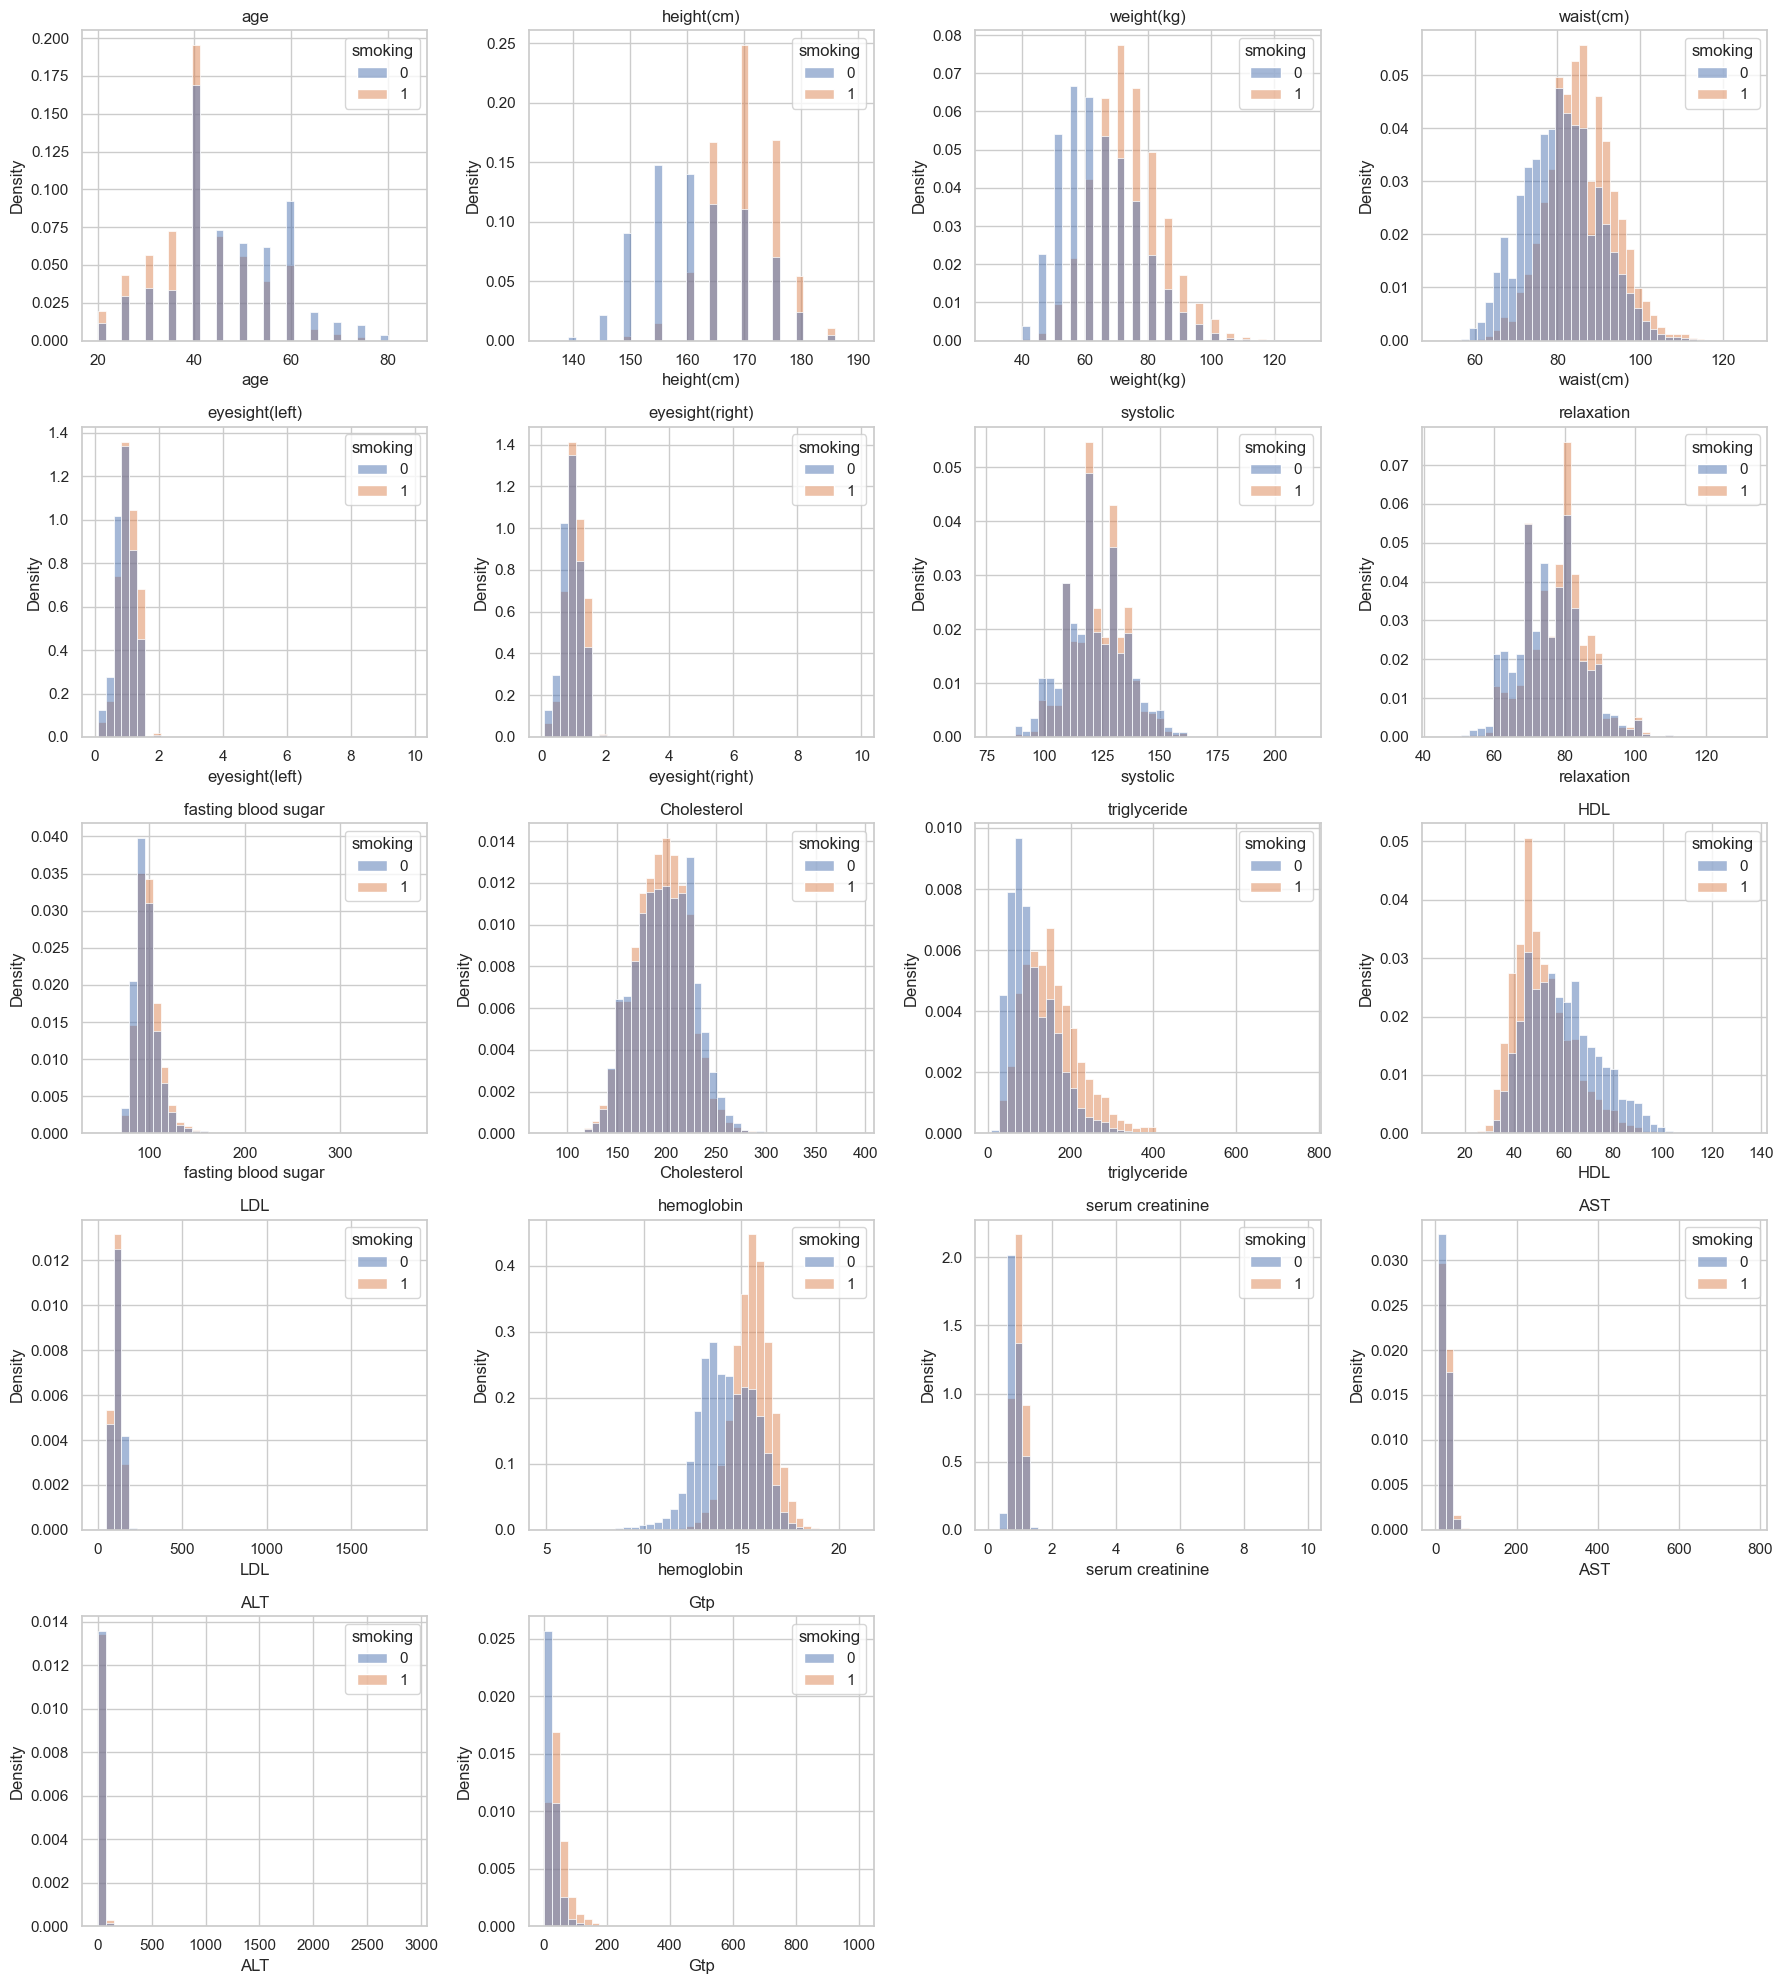

In [7]:
n_cols = 4
n_rows = int(np.ceil(len(continuous_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=train, x=col, hue=TARGET, bins=40, stat='density', common_norm=False, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

,feature,auc_raw,auc_direction_adjusted,direction
15,hemoglobin,0.766143,0.766143,positive
1,height(cm),0.756446,0.756446,positive
20,Gtp,0.745813,0.745813,positive
2,weight(kg),0.711594,0.711594,positive
12,triglyceride,0.703048,0.703048,positive
17,serum creatinine,0.666822,0.666822,positive
13,HDL,0.341312,0.658688,negative
3,waist(cm),0.652910,0.652910,positive
19,ALT,0.631980,0.631980,positive
0,age,0.381027,0.618973,negative


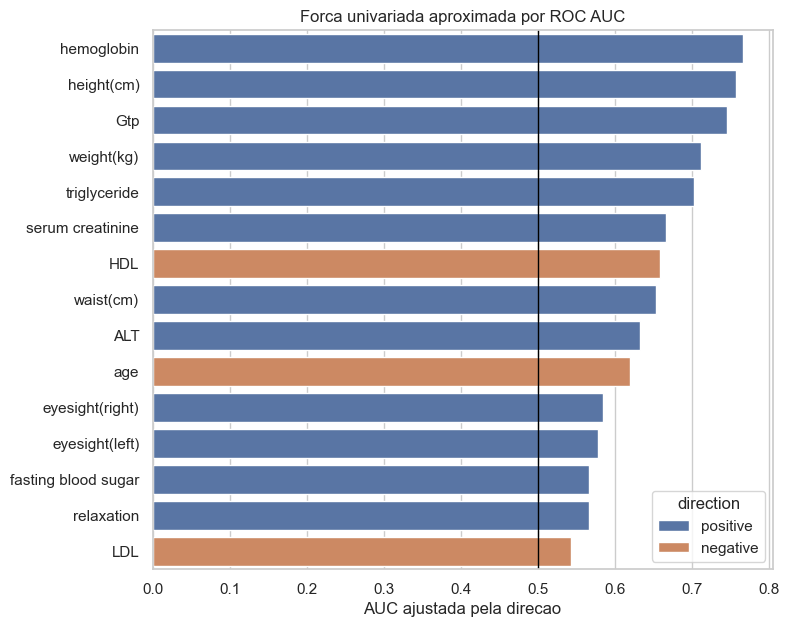

In [8]:
auc_univariate = []
for col in feature_cols:
    values = train[col]
    if values.nunique() <= 1:
        continue
    auc = roc_auc_score(train[TARGET], values)
    auc_univariate.append({
        'feature': col,
        'auc_raw': auc,
        'auc_direction_adjusted': max(auc, 1 - auc),
        'direction': 'positive' if auc >= 0.5 else 'negative',
    })

auc_univariate = pd.DataFrame(auc_univariate).sort_values('auc_direction_adjusted', ascending=False)
display(auc_univariate.head(20))

plt.figure(figsize=(8, 7))
sns.barplot(data=auc_univariate.head(15), y='feature', x='auc_direction_adjusted', hue='direction', dodge=False)
plt.axvline(0.5, color='black', lw=1)
plt.title('Forca univariada aproximada por ROC AUC')
plt.xlabel('AUC ajustada pela direcao')
plt.ylabel('')
plt.show()

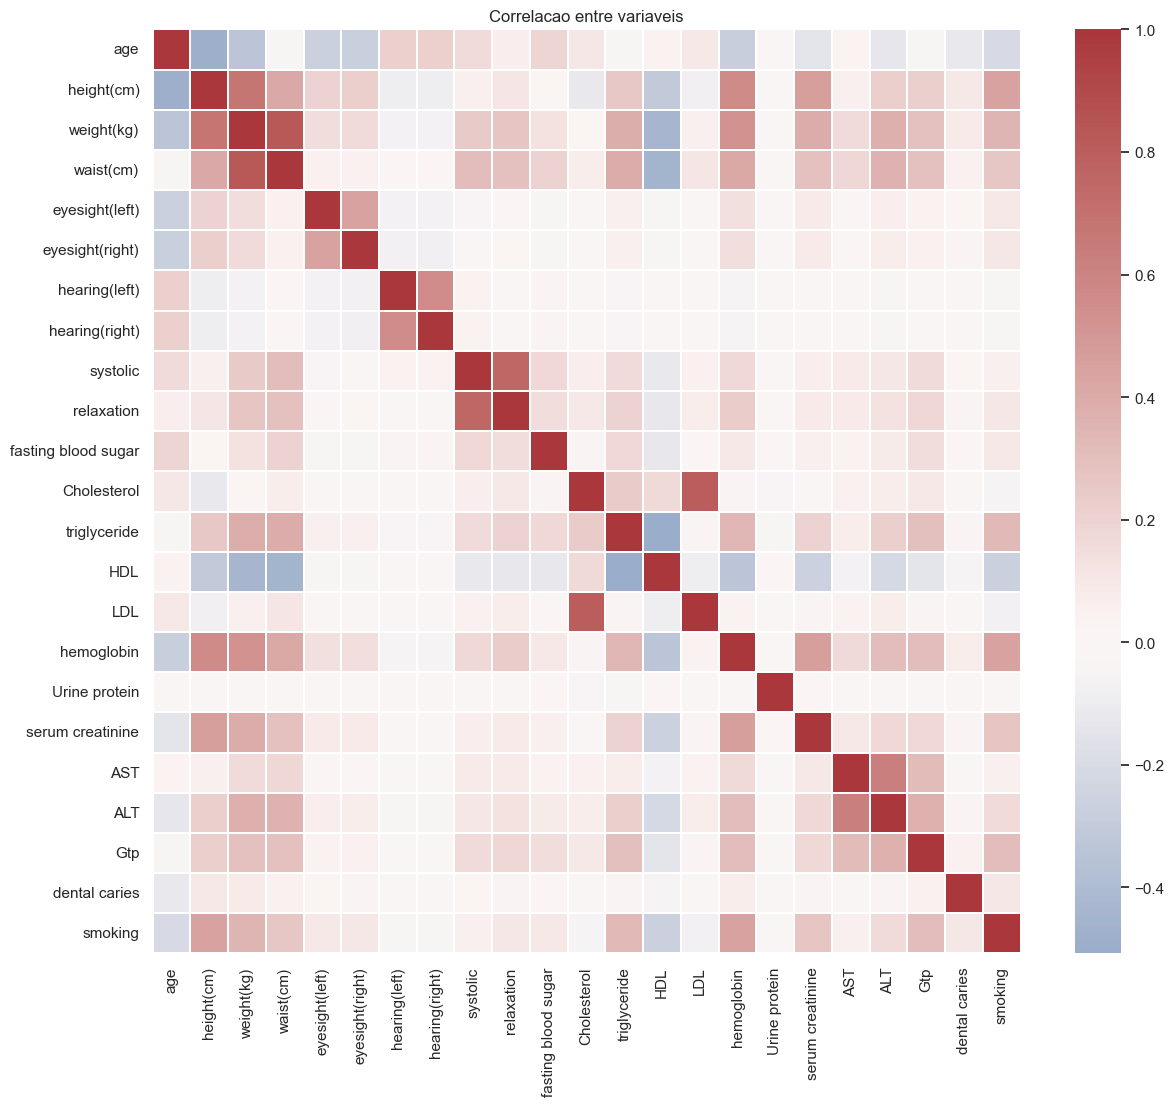

,corr_with_target
hemoglobin,0.450679
height(cm),0.447111
weight(kg),0.351748
triglyceride,0.331975
Gtp,0.305561
serum creatinine,0.272979
HDL,-0.271186
waist(cm),0.262715
age,-0.206033
ALT,0.163016


In [9]:
corr = train[feature_cols + [TARGET]].corr(numeric_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='vlag', center=0, square=False, linewidths=0.2)
plt.title('Correlacao entre variaveis')
plt.show()

corr_target = corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
display(corr_target.to_frame('corr_with_target').head(20))

## 4. Feature engineering

In [10]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Cria atributos derivados sem usar a variavel alvo."""
    X = df.copy()
    eps = 1e-6

    X['BMI'] = X['weight(kg)'] / ((X['height(cm)'] / 100) ** 2)
    X['waist_to_height'] = X['waist(cm)'] / (X['height(cm)'] + eps)
    X['pulse_pressure'] = X['systolic'] - X['relaxation']
    X['mean_arterial_pressure'] = (X['systolic'] + 2 * X['relaxation']) / 3

    X['eyesight_mean'] = (X['eyesight(left)'] + X['eyesight(right)']) / 2
    X['eyesight_diff_abs'] = (X['eyesight(left)'] - X['eyesight(right)']).abs()
    X['hearing_sum'] = X['hearing(left)'] + X['hearing(right)']
    X['hearing_any_issue'] = ((X['hearing(left)'] > 1) | (X['hearing(right)'] > 1)).astype(int)

    X['chol_hdl_ratio'] = X['Cholesterol'] / (X['HDL'] + eps)
    X['ldl_hdl_ratio'] = X['LDL'] / (X['HDL'] + eps)
    X['tg_hdl_ratio'] = X['triglyceride'] / (X['HDL'] + eps)
    X['non_hdl_cholesterol'] = X['Cholesterol'] - X['HDL']
    X['ast_alt_ratio'] = X['AST'] / (X['ALT'] + eps)
    X['gtp_log1p'] = np.log1p(X['Gtp'])
    X['triglyceride_log1p'] = np.log1p(X['triglyceride'])

    X['high_fasting_glucose'] = (X['fasting blood sugar'] >= 126).astype(int)
    X['high_blood_pressure'] = ((X['systolic'] >= 140) | (X['relaxation'] >= 90)).astype(int)
    X['has_urine_protein'] = (X['Urine protein'] > 1).astype(int)

    return X

train_fe = add_features(train.drop(columns=[TARGET]))
test_fe = add_features(test)

new_features = [c for c in train_fe.columns if c not in test.columns]
print(f'Novas features ({len(new_features)}):')
print(new_features)
display(train_fe[new_features].head())

Novas features (18):
['BMI', 'waist_to_height', 'pulse_pressure', 'mean_arterial_pressure', 'eyesight_mean', 'eyesight_diff_abs', 'hearing_sum', 'hearing_any_issue', 'chol_hdl_ratio', 'ldl_hdl_ratio', 'tg_hdl_ratio', 'non_hdl_cholesterol', 'ast_alt_ratio', 'gtp_log1p', 'triglyceride_log1p', 'high_fasting_glucose', 'high_blood_pressure', 'has_urine_protein']


,BMI,waist_to_height,pulse_pressure,mean_arterial_pressure,eyesight_mean,eyesight_diff_abs,hearing_sum,hearing_any_issue,chol_hdl_ratio,ldl_hdl_ratio,tg_hdl_ratio,non_hdl_cholesterol,ast_alt_ratio,gtp_log1p,triglyceride_log1p,high_fasting_glucose,high_blood_pressure,has_urine_protein
0,22.038567,0.490909,48,103.000000,0.55,0.1,2,0,4.300000,1.875000,7.500000,132,0.880000,3.332205,5.707110,0,0,0
1,23.875115,0.539394,63,104.000000,0.65,0.1,4,1,3.403509,2.210526,0.964912,137,1.173913,3.637586,4.025352,1,1,0
2,25.951557,0.476471,43,89.333333,0.45,0.1,2,0,3.955555,2.066667,4.377778,133,0.870968,3.988984,5.288267,0,0,0
3,29.320988,0.583333,43,102.333333,1.35,0.3,2,0,4.736842,2.684210,5.342105,142,0.740741,3.433987,5.318120,0,0,0
4,22.038567,0.487879,45,91.000000,1.25,0.5,2,0,3.522727,2.113636,1.977273,111,1.461538,2.890372,4.477337,0,0,0


In [11]:
fe_corr = pd.concat([train_fe.drop(columns=[ID_COL]), train[TARGET]], axis=1).corr(numeric_only=True)[TARGET].drop(TARGET)
display(fe_corr.sort_values(key=np.abs, ascending=False).head(25).to_frame('corr_with_target'))

,corr_with_target
hemoglobin,0.450679
height(cm),0.447111
gtp_log1p,0.408550
weight(kg),0.351748
triglyceride_log1p,0.346574
triglyceride,0.331975
tg_hdl_ratio,0.331813
Gtp,0.305561
serum creatinine,0.272979
HDL,-0.271186


## 5. Validação e pipelines para Regressão Logística

In [12]:
X = train.drop(columns=[TARGET])
y = train[TARGET]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_preprocessor(use_feature_engineering=False, use_power_transform=False):
    sample = add_features(X.drop(columns=[ID_COL])) if use_feature_engineering else X.drop(columns=[ID_COL])
    cat_cols = [
        c for c in sample.columns
        if sample[c].nunique() <= 10 or c in ['hearing_any_issue', 'high_fasting_glucose', 'high_blood_pressure', 'has_urine_protein']
    ]
    num_cols = [c for c in sample.columns if c not in cat_cols]

    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if use_power_transform:
        numeric_steps.append(('power', PowerTransformer(method='yeo-johnson', standardize=False)))
    numeric_steps.append(('scaler', StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )
    return preprocessor

feature_engineering_step = FunctionTransformer(lambda df: add_features(df.drop(columns=[ID_COL])), validate=False)
raw_feature_step = FunctionTransformer(lambda df: df.drop(columns=[ID_COL]), validate=False)

def make_lr_pipeline(use_feature_engineering=False, use_power_transform=False, **lr_kwargs):
    transform_step = feature_engineering_step if use_feature_engineering else raw_feature_step
    return Pipeline([
        ('features', transform_step),
        ('preprocess', make_preprocessor(use_feature_engineering, use_power_transform)),
        ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1, **lr_kwargs)),
    ])

In [13]:
models = {
    'LR_baseline_scaled': make_lr_pipeline(use_feature_engineering=False, C=1.0, penalty='l2', solver='lbfgs'),
    'LR_feature_engineering_l2': make_lr_pipeline(use_feature_engineering=True, C=1.0, penalty='l2', solver='lbfgs'),
    'LR_feature_engineering_balanced_l2': make_lr_pipeline(use_feature_engineering=True, C=1.0, penalty='l2', solver='lbfgs', class_weight='balanced'),
    'LR_feature_engineering_power_l2': make_lr_pipeline(use_feature_engineering=True, use_power_transform=True, C=1.0, penalty='l2', solver='lbfgs'),
}

cv_results = []
for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        return_train_score=True,
    )
    cv_results.append({
        'model': name,
        'mean_train_auc': scores['train_score'].mean(),
        'std_train_auc': scores['train_score'].std(),
        'mean_valid_auc': scores['test_score'].mean(),
        'std_valid_auc': scores['test_score'].std(),
    })

cv_results = pd.DataFrame(cv_results).sort_values('mean_valid_auc', ascending=False)
display(cv_results)

/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/line

,model,mean_train_auc,std_train_auc,mean_valid_auc,std_valid_auc
3,LR_feature_engineering_power_l2,0.844741,0.000466,0.844519,0.001733
1,LR_feature_engineering_l2,0.843167,0.000423,0.842963,0.001852
2,LR_feature_engineering_balanced_l2,0.842899,0.000432,0.842694,0.001845
0,LR_baseline_scaled,0.834475,0.000462,0.834364,0.002040


## 6. Tuning do melhor pipeline de Regressão Logística

In [14]:
base_pipe = make_lr_pipeline(use_feature_engineering=True, use_power_transform=True, solver='saga')

param_grid = [
    {
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0],
        'model__class_weight': [None, 'balanced'],
    },
    {
        'model__penalty': ['elasticnet'],
        'model__l1_ratio': [0.15, 0.5, 0.85],
        'model__C': [0.03, 0.1, 0.3, 1.0],
        'model__class_weight': [None, 'balanced'],
    },
]

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid.fit(X, y)

print('Melhor ROC AUC CV:', grid.best_score_)
print('Melhores parametros:', grid.best_params_)

results_grid = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
display(results_grid[['mean_test_score', 'std_test_score', 'mean_fit_time', 'param_model__penalty', 'param_model__C', 'param_model__class_weight', 'param_model__l1_ratio']].head(15))

Fitting 5 folds for each of 44 candidates, totalling 220 fits


/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedroascef/Desktop/Practice/TrabalhoMC906/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: 

Melhor ROC AUC CV: 0.844688633440238
Melhores parametros: {'model__C': 3.0, 'model__class_weight': None, 'model__penalty': 'l1'}


,mean_test_score,std_test_score,mean_fit_time,param_model__penalty,param_model__C,param_model__class_weight,param_model__l1_ratio
16,0.844689,0.001773,417.277053,l1,3.0,None,NaN
12,0.844655,0.001762,289.211004,l1,1.0,None,NaN
17,0.844634,0.001758,115.431981,l2,3.0,None,NaN
40,0.844627,0.001757,177.680832,elasticnet,1.0,None,0.85
39,0.844602,0.001752,98.891187,elasticnet,1.0,None,0.50
38,0.844583,0.001750,75.976672,elasticnet,1.0,None,0.15
8,0.844578,0.001752,39.052480,l1,0.3,None,NaN
13,0.844576,0.001750,48.703298,l2,1.0,None,NaN
34,0.844557,0.001748,40.748493,elasticnet,0.3,None,0.85
18,0.844477,0.001782,421.945107,l1,3.0,balanced,NaN


## 7. Avaliação holdout do melhor modelo

Holdout ROC AUC: 0.841187


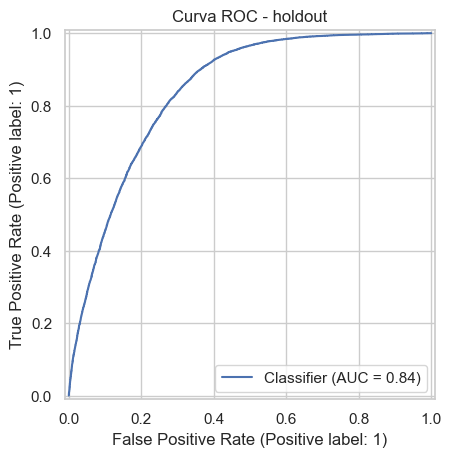

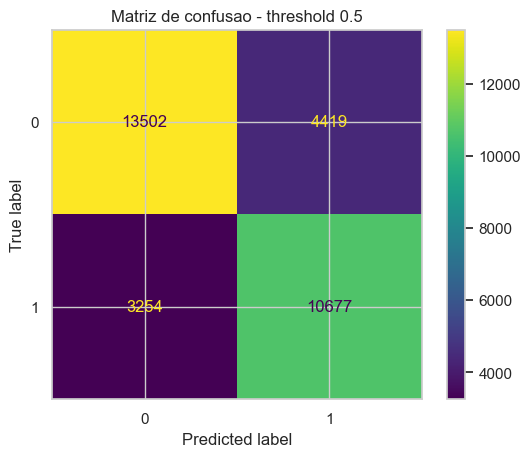

In [15]:
best_pipe = grid.best_estimator_
best_pipe.fit(X_train, y_train)
valid_proba = best_pipe.predict_proba(X_valid)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_proba)
print(f'Holdout ROC AUC: {valid_auc:.6f}')

RocCurveDisplay.from_predictions(y_valid, valid_proba)
plt.title('Curva ROC - holdout')
plt.show()

threshold = 0.5
valid_pred = (valid_proba >= threshold).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_valid, valid_pred)).plot(values_format='d')
plt.title(f'Matriz de confusao - threshold {threshold}')
plt.show()

In [16]:
error_df = X_valid.copy()
error_df['y_true'] = y_valid.values
error_df['proba_smoking'] = valid_proba
error_df['abs_error'] = np.abs(error_df['y_true'] - error_df['proba_smoking'])

print('Casos mais confiantes e errados:')
display(error_df.sort_values('abs_error', ascending=False).head(15))

for col in ['age', 'height(cm)', 'weight(kg)', 'dental caries']:
    tmp = error_df.copy()
    if tmp[col].nunique() > 8:
        tmp[f'{col}_bin'] = pd.qcut(tmp[col], q=6, duplicates='drop')
        group_col = f'{col}_bin'
    else:
        group_col = col
    display(
        tmp.groupby(group_col, observed=False)
        .apply(lambda g: pd.Series({
            'n': len(g),
            'auc': roc_auc_score(g['y_true'], g['proba_smoking']) if g['y_true'].nunique() == 2 else np.nan,
            'target_rate': g['y_true'].mean(),
            'pred_rate': g['proba_smoking'].mean(),
        }))
    )

Casos mais confiantes e errados:


,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,y_true,proba_smoking,abs_error
80793,80793,35,135,45,71.0,0.9,0.5,1,1,118,76,101,126,76,36,70,15.1,1,1.0,37,73,58,0,1,0.003299,0.996701
110441,110441,40,145,45,73.0,0.7,0.1,1,1,108,80,78,228,94,67,141,13.2,1,0.8,42,58,17,0,1,0.003592,0.996408
147079,147079,45,145,75,85.0,1.5,1.5,1,1,125,83,102,226,69,89,123,14.0,1,0.9,18,18,18,1,1,0.003756,0.996244
125640,125640,50,145,55,77.0,1.0,1.5,1,1,130,80,114,189,35,59,124,13.4,1,0.9,21,15,25,0,1,0.004725,0.995275
67243,67243,50,145,50,65.0,1.0,1.2,1,1,103,64,101,183,64,87,83,13.2,1,0.7,32,29,23,0,1,0.005435,0.994565
41175,41175,60,140,55,87.0,0.9,0.7,1,1,118,77,101,147,103,52,74,14.4,1,0.5,26,29,28,0,1,0.006166,0.993834
11281,11281,65,145,70,91.0,0.5,0.8,2,2,110,75,93,179,126,45,109,13.3,1,0.8,16,15,14,0,1,0.006673,0.993327
157152,157152,45,155,50,67.0,1.0,0.8,1,1,123,73,102,259,48,79,170,13.5,1,0.7,32,20,13,0,1,0.008558,0.991442
55095,55095,70,150,60,88.0,0.5,0.6,1,1,135,80,101,220,110,52,145,11.3,1,0.7,28,16,19,0,1,0.009150,0.990850
74244,74244,40,155,60,74.0,1.5,1.5,1,1,137,83,95,198,71,73,112,12.5,1,0.9,32,71,14,1,1,0.009807,0.990193


,n,auc,target_rate,pred_rate
age_bin,,,,
"(19.999, 35.0]",7544.0,0.680279,0.569857,0.607721
"(35.0, 40.0]",9371.0,0.871396,0.474442,0.450614
"(40.0, 50.0]",6856.0,0.876808,0.415257,0.395284
"(50.0, 60.0]",6432.0,0.870955,0.312034,0.316508
"(60.0, 85.0]",1649.0,0.816354,0.201334,0.258595


,n,auc,target_rate,pred_rate
height(cm)_bin,,,,
"(134.999, 155.0]",6871.0,0.801163,0.058216,0.069197
"(155.0, 160.0]",4526.0,0.858889,0.243261,0.254243
"(160.0, 165.0]",5950.0,0.755194,0.535462,0.501862
"(165.0, 170.0]",7556.0,0.708472,0.630889,0.629370
"(170.0, 175.0]",4943.0,0.688630,0.652438,0.666379
"(175.0, 190.0]",2006.0,0.679073,0.624128,0.657008


,n,auc,target_rate,pred_rate
weight(kg)_bin,,,,
"(29.999, 55.0]",7763.0,0.894177,0.151874,0.170448
"(55.0, 60.0]",4273.0,0.869303,0.337702,0.322734
"(60.0, 65.0]",4779.0,0.811540,0.483783,0.456080
"(65.0, 70.0]",4877.0,0.755891,0.553414,0.544878
"(70.0, 80.0]",6558.0,0.728533,0.606587,0.606333
"(80.0, 125.0]",3602.0,0.671834,0.644087,0.684089


,n,auc,target_rate,pred_rate
dental caries,,,,
0,25625.0,0.843460,0.413776,0.412963
1,6227.0,0.819011,0.534447,0.545600


## 8. Interpretabilidade por coeficientes

,feature,coef,abs_coef,odds_ratio_per_scaled_unit
30,triglyceride_log1p,11.113581,11.113581,67075.963415
10,triglyceride,-10.414855,10.414855,0.000030
2,weight(kg),10.272914,10.272914,28938.092789
18,BMI,-7.715069,7.715069,0.000446
1,height(cm),-3.662560,3.662560,0.025667
3,waist(cm),-2.801562,2.801562,0.060715
19,waist_to_height,2.584074,2.584074,13.251014
25,ldl_hdl_ratio,1.400521,1.400521,4.057315
12,LDL,-1.098677,1.098677,0.333312
17,Gtp,1.069836,1.069836,2.914901


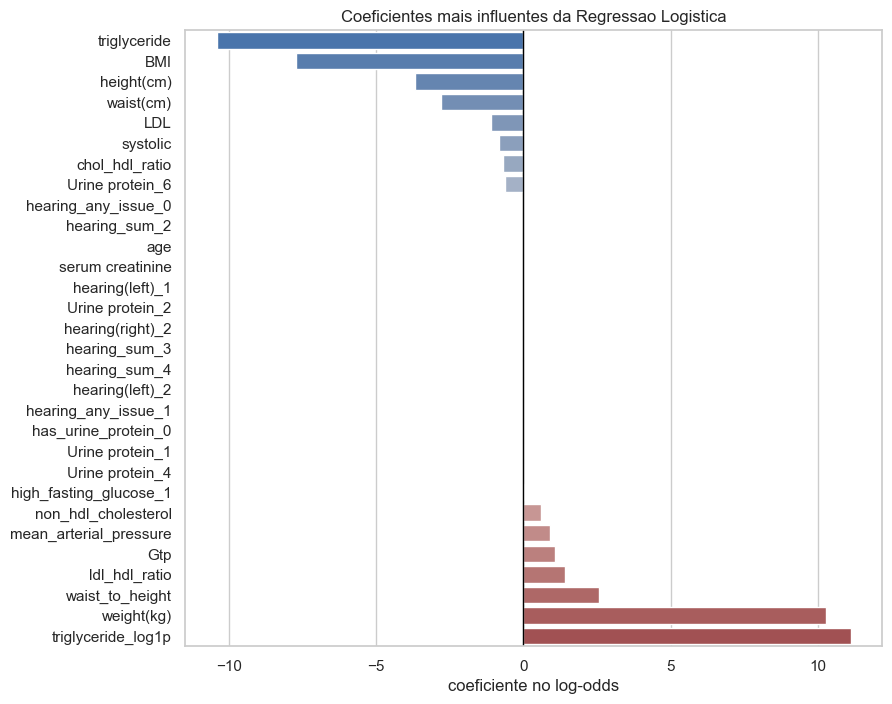

In [17]:
final_model = grid.best_estimator_
final_model.fit(X, y)

preprocess = final_model.named_steps['preprocess']
feature_names = preprocess.get_feature_names_out()
coefs = final_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs),
    'odds_ratio_per_scaled_unit': np.exp(coefs),
}).sort_values('abs_coef', ascending=False)

display(coef_df.head(30))

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = pd.concat([coef_df.head(15), coef_df.tail(15)]).sort_values('coef')
sns.barplot(data=plot_df, y='feature', x='coef', ax=ax, palette='vlag')
ax.axvline(0, color='black', lw=1)
ax.set_title('Coeficientes mais influentes da Regressao Logistica')
ax.set_xlabel('coeficiente no log-odds')
ax.set_ylabel('')
plt.show()

## 9. Treino final e submissão

In [19]:
final_pipe = grid.best_estimator_
final_pipe.fit(X, y)

test_proba = final_pipe.predict_proba(test)[:, 1]
submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: test_proba,
})

submission_path = DATA_DIR / 'submission_logistic_regression_v2.csv'
submission.to_csv(submission_path, index=False)